# 03 · How a short straddle earns when the index stays calm and loses when it moves

Part 3 of 5. Before running the strategy, this notebook shows what it does, one trade at a time.

**The trade.** Sell an at-the-money straddle (a call and a put at the same strike) with one month to expiry. The seller receives the premium up front and pays the absolute move of the index at expiry. The premium, for an at-the-money option, is close to `0.8 * S * sigma * sqrt(T)`.

**The hedge.** Left alone, the seller is exposed to the direction of the market. Each day the position is made neutral to small moves by trading the index (delta-hedging). What remains is a bet on volatility:

```
daily P&L of a hedged short option  ≈  0.5 * Gamma * S^2 * (implied variance − realized variance) * dt
```

The seller earns when the market moves less than the implied volatility charged, and loses when it moves more. That is the volatility risk premium being harvested, and its cost.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from vrp.plots import PALETTE, style
from vrp.pricing import call_price, put_price, straddle_delta, straddle_gamma, straddle_price, straddle_vega

## Price, delta and gamma of the straddle

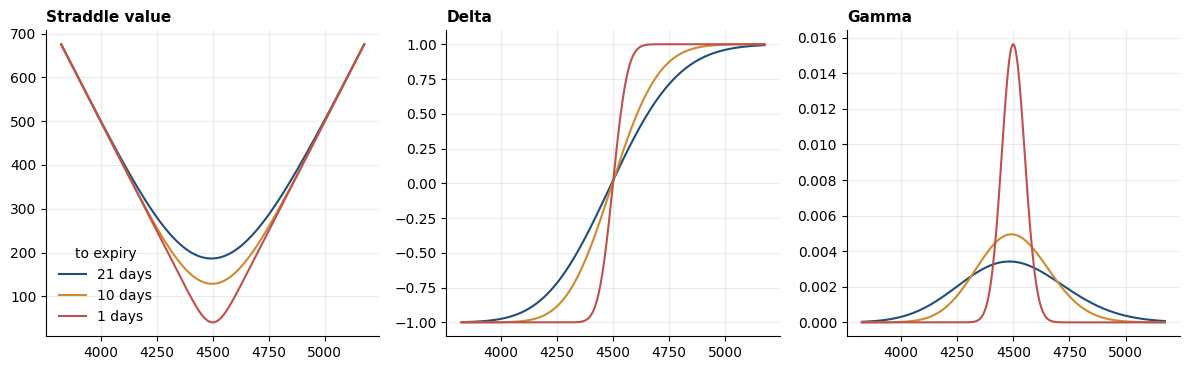

In [2]:
S0, TAU, VOL = 4500.0, 21 / 252, 0.18
spots = np.linspace(0.85 * S0, 1.15 * S0, 300)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for tau_days, color in zip((21, 10, 1), (PALETTE[0], PALETTE[4], PALETTE[1])):
    tau = tau_days / 252
    axes[0].plot(spots, [straddle_price(s, S0, tau, VOL) for s in spots], color=color, label=f"{tau_days} days")
    axes[1].plot(spots, [straddle_delta(s, S0, tau, VOL) for s in spots], color=color)
    axes[2].plot(spots, [straddle_gamma(s, S0, tau, VOL) for s in spots], color=color)
axes[0].legend(frameon=False, title="to expiry")
style(axes[0], "Straddle value")
style(axes[1], "Delta")
style(axes[2], "Gamma")
plt.tight_layout()
plt.close(fig)
fig

The plots show the straddle as a buyer holds it; the seller holds the opposite. Delta runs from −1 to +1: below the strike the straddle behaves like a short position in the index, above it like a long one, so the hedge has to be adjusted as the index moves. Gamma is the speed at which delta changes. It peaks at the strike and grows sharply as expiry gets close, which is why the last days of a short straddle are the most sensitive to a sudden move.

## The rule of thumb and the greeks are correct

In [3]:
rows = []
for vol in (0.10, 0.15, 0.20, 0.30, 0.40):
    exact = straddle_price(S0, S0, TAU, vol)
    approx = 0.8 * S0 * vol * np.sqrt(TAU)
    rows.append({"vol": vol, "exact price": exact, "0.8 S vol sqrt(T)": approx, "error (%)": 100 * (approx / exact - 1)})
pd.DataFrame(rows).set_index("vol").round(2)

,exact price,0.8 S vol sqrt(T),error (%)
vol,,,
0.10,103.64,103.92,0.27
0.15,155.46,155.88,0.27
0.20,207.27,207.85,0.28
0.30,310.85,311.77,0.30
0.40,414.36,415.69,0.32


In [4]:
K, RATE = 4450.0, 0.03
h = 1e-3 * S0
fd_delta = (straddle_price(S0 + h, K, TAU, VOL, RATE) - straddle_price(S0 - h, K, TAU, VOL, RATE)) / (2 * h)
fd_gamma = (straddle_price(S0 + h, K, TAU, VOL, RATE) - 2 * straddle_price(S0, K, TAU, VOL, RATE)
            + straddle_price(S0 - h, K, TAU, VOL, RATE)) / h**2
fd_vega = (straddle_price(S0, K, TAU, VOL + 1e-4, RATE) - straddle_price(S0, K, TAU, VOL - 1e-4, RATE)) / 2e-4
parity = call_price(S0, K, TAU, VOL, RATE) - put_price(S0, K, TAU, VOL, RATE) - (S0 - K * np.exp(-RATE * TAU))

greeks = pd.DataFrame({
    "formula": [straddle_delta(S0, K, TAU, VOL, RATE), straddle_gamma(S0, K, TAU, VOL, RATE), straddle_vega(S0, K, TAU, VOL, RATE)],
    "finite difference": [fd_delta, fd_gamma, fd_vega],
}, index=["delta", "gamma", "vega"])
greeks["relative gap"] = (greeks["formula"] / greeks["finite difference"] - 1).abs()
print(f"put-call parity error: {parity:.2e}")
greeks

put-call parity error: 2.27e-13


,formula,finite difference,relative gap
delta,0.227513,0.227497,7.081638e-05
gamma,0.003273,0.003273,2.672642e-05
vega,994.054251,994.054240,1.047981e-08


The closed-form greeks match numerical derivatives to within 0.01%, and put-call parity holds to machine precision. The straddle price is within 0.3% of the rule of thumb across volatilities from 10% to 40%. These checks also run as unit tests (`tests/test_pricing.py`).

## Two real trades, day by day

In [5]:
from vrp.data import load_market_data
from vrp.backtest import StraddleConfig, backtest_short_straddle

data = load_market_data("yahoo", "1990-01-01", "2026-09-25").loc["2020-01-01":]
spx, vix = data["spx"], data["vix"]
config = StraddleConfig()
daily, trades = backtest_short_straddle(spx, vix, config=config)

best, worst = trades.loc[trades["pnl"].idxmax()], trades.loc[trades["pnl"].idxmin()]
trades.loc[[best.name, worst.name], ["entry", "expiry", "implied_vol", "realized_vol", "premium", "pnl"]].round(
    {"implied_vol": 3, "realized_vol": 3, "premium": 0, "pnl": 0}).set_index("entry")

,expiry,implied_vol,realized_vol,premium,pnl
entry,,,,,
2020-10-30,2020-12-01,0.36,0.176,82927.0,24427.0
2020-03-04,2020-04-02,0.30,0.934,69054.0,-82238.0


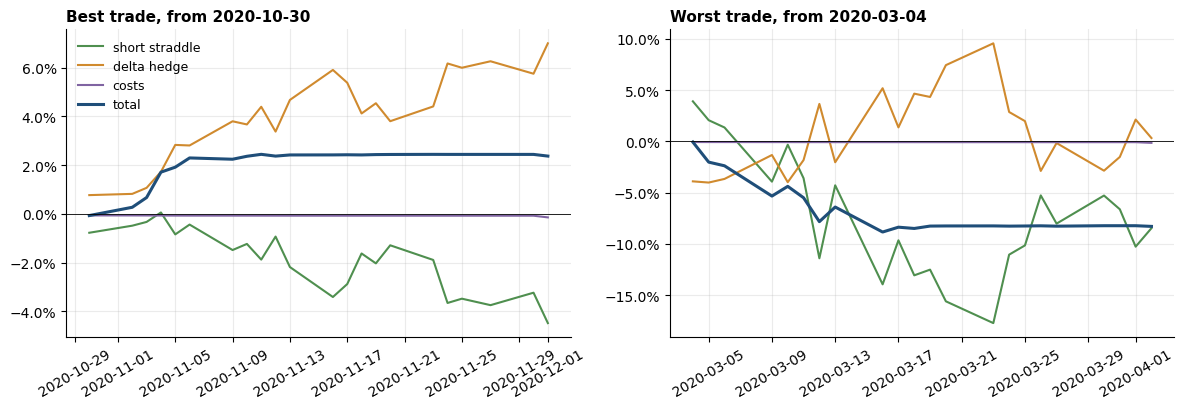

In [6]:
def trade_panel(ax, trade, title):
    window = daily.loc[trade["entry"]:trade["expiry"]]
    capital = config.capital
    ax.plot(window.index, window["option_pnl"].cumsum() / capital, color=PALETTE[2], label="short straddle")
    ax.plot(window.index, window["hedge_pnl"].cumsum() / capital, color=PALETTE[4], label="delta hedge")
    ax.plot(window.index, -window["costs"].cumsum() / capital, color=PALETTE[3], label="costs")
    ax.plot(window.index, window["pnl"].cumsum() / capital, color=PALETTE[0], lw=2.2, label="total")
    ax.axhline(0, color="black", lw=0.6)
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
    style(ax, title)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
trade_panel(axes[0], best, f"Best trade, from {best['entry'].date()}")
trade_panel(axes[1], worst, f"Worst trade, from {worst['entry'].date()}")
axes[0].legend(frameon=False, fontsize=9)
for ax in axes:
    ax.tick_params(axis="x", labelrotation=30)
plt.tight_layout()
plt.close(fig)
fig

Each panel shows the cumulative P&L of the two legs and their sum. The short straddle (green) and the delta hedge (orange) largely offset each other, and what is left (blue) is the volatility bet. Costs are too small to see.

- **Best trade**, entered on 30 October 2020 with a VIX near 38: the index then realized about 18% volatility against 36% priced in. The total ends at +2.4% of capital, out of a premium of 8.3%.
- **Worst trade**, entered on 4 March 2020: the index realized about 93% volatility against 30% priced in. The hedge earned money on the swings but far less than the option leg lost, and the trade ends at −8.2% of capital, more than the 6.9% premium collected at entry.